# Python Machine Learning Diploma - Orientation Session

Today's Outline:
- Diploma Orientation
- Full Data Science Projects:
    - House Prices Prediction [Regression]
    - Titanic Survivals Prediction [Classification]

==========

## The Data Science Process

In [292]:
from IPython.display import Image
Image("imgs/ml-process.jpeg")

FileNotFoundError: No such file or directory: 'imgs/ml-process.jpeg'

FileNotFoundError: No such file or directory: 'imgs/ml-process.jpeg'

<IPython.core.display.Image object>

==========

## Full Data Science Project - Titanic Survivals Prediction [Classification]

Predict survival on the Titanic and get familiar with ML basics
- https://www.kaggle.com/c/titanic

### Import Libraries

In [297]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set()

### Importing Dataset

In [299]:
data = pd.read_csv('data/003 titanic.csv')

In [300]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [301]:
data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [302]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Data Cleaning & Pre-processing

##### Dealing with Missing Data

In [305]:
data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: >

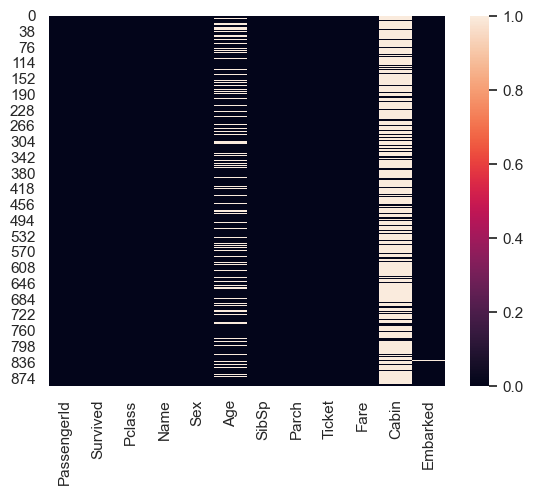

In [306]:
sns.heatmap(data.isna())

In [307]:
data['Age'] = data['Age'].fillna(data['Age'].mean())

{'whiskers': [<matplotlib.lines.Line2D at 0x1978fd71580>,
 'caps': [<matplotlib.lines.Line2D at 0x1978fbb4380>,
 'boxes': [<matplotlib.lines.Line2D at 0x1978fe58c20>],
 'medians': [<matplotlib.lines.Line2D at 0x1978fbb5160>],
 'fliers': [<matplotlib.lines.Line2D at 0x1978fbb4b30>],
 'means': []}

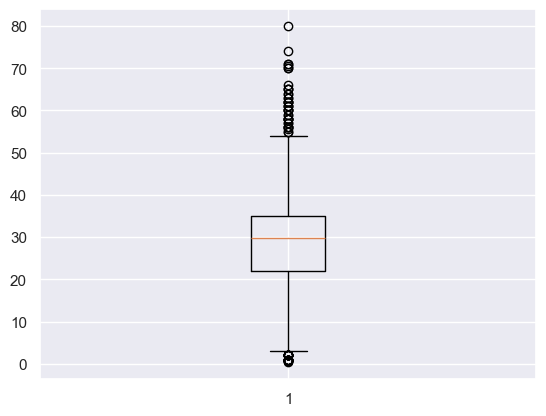

In [308]:
plt.boxplot(data['Age'])

In [309]:
data.drop('Cabin', axis=1 ,inplace=True)

In [310]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [311]:
data.dropna(inplace=True)

In [312]:
data.shape

(889, 11)

In [313]:
data.duplicated().sum()

0

In [314]:
data.describe().round()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,889.0,889.0,889.0,889.0,889.0,889.0,889.0
mean,446.0,0.0,2.0,30.0,1.0,0.0,32.0
std,257.0,0.0,1.0,13.0,1.0,1.0,50.0
min,1.0,0.0,1.0,0.0,0.0,0.0,0.0
25%,224.0,0.0,2.0,22.0,0.0,0.0,8.0
50%,446.0,0.0,3.0,30.0,0.0,0.0,14.0
75%,668.0,1.0,3.0,35.0,1.0,0.0,31.0
max,891.0,1.0,3.0,80.0,8.0,6.0,512.0


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >], dtype=object)

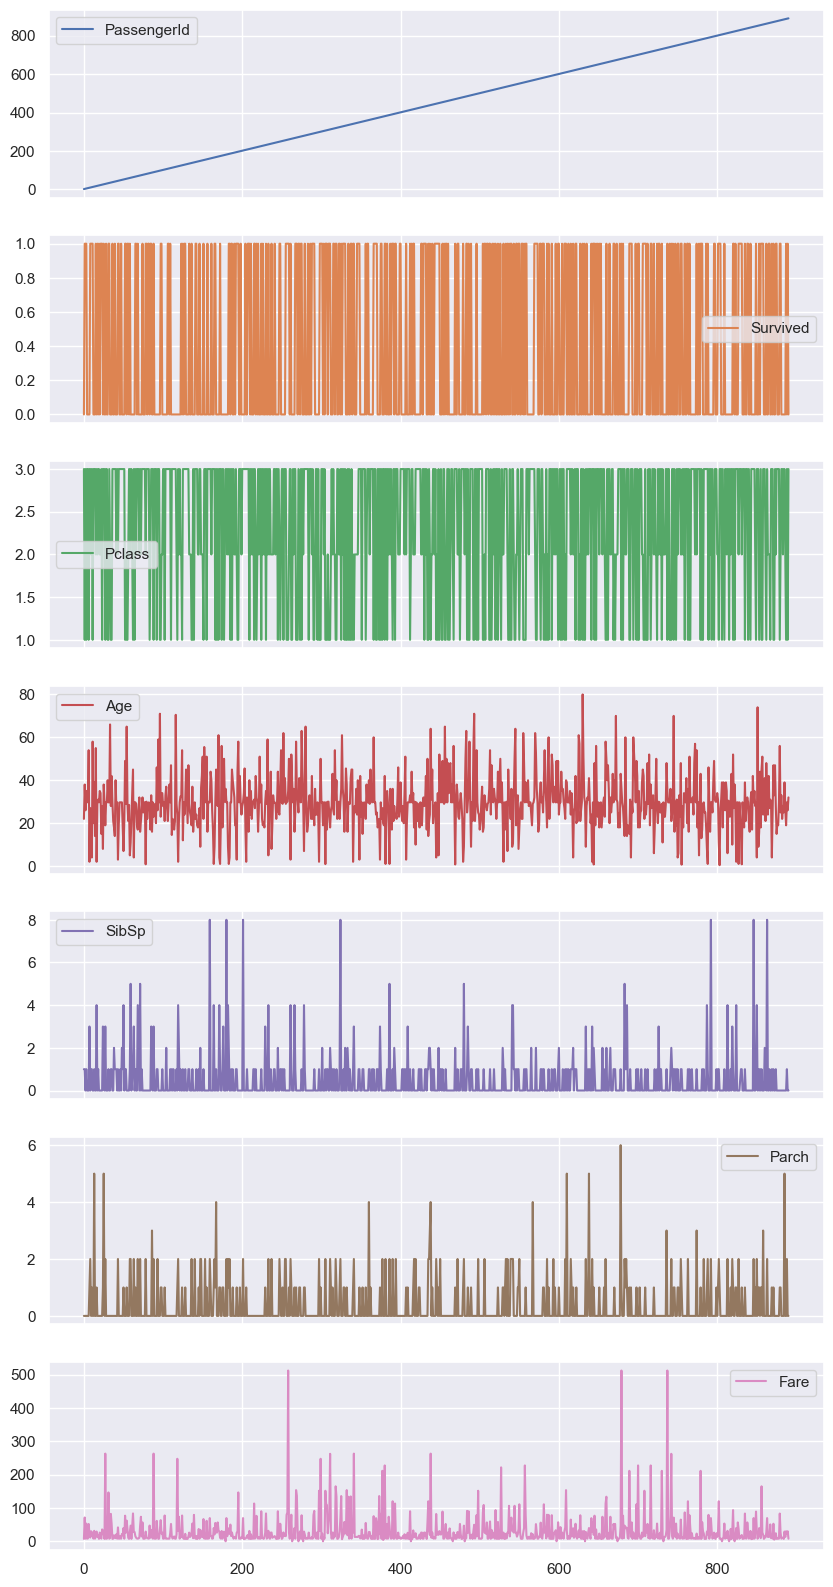

In [315]:
data.plot(subplots=True , figsize=(10,20))

{'whiskers': [<matplotlib.lines.Line2D at 0x197892bbd70>,
 'caps': [<matplotlib.lines.Line2D at 0x197892bbb90>,
 'boxes': [<matplotlib.lines.Line2D at 0x19786a51d90>],
 'medians': [<matplotlib.lines.Line2D at 0x19786cae5a0>],
 'fliers': [<matplotlib.lines.Line2D at 0x19786cadac0>],
 'means': []}

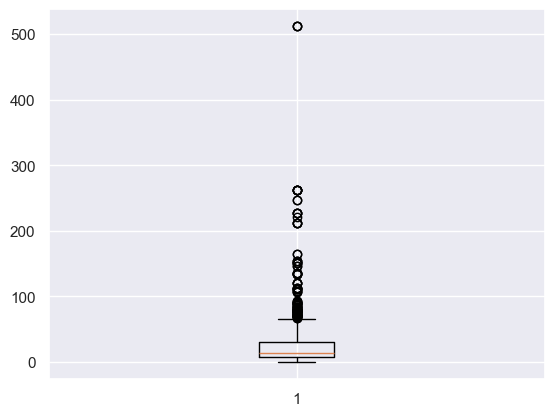

In [316]:
plt.boxplot(data['Fare'])

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >], dtype=object)

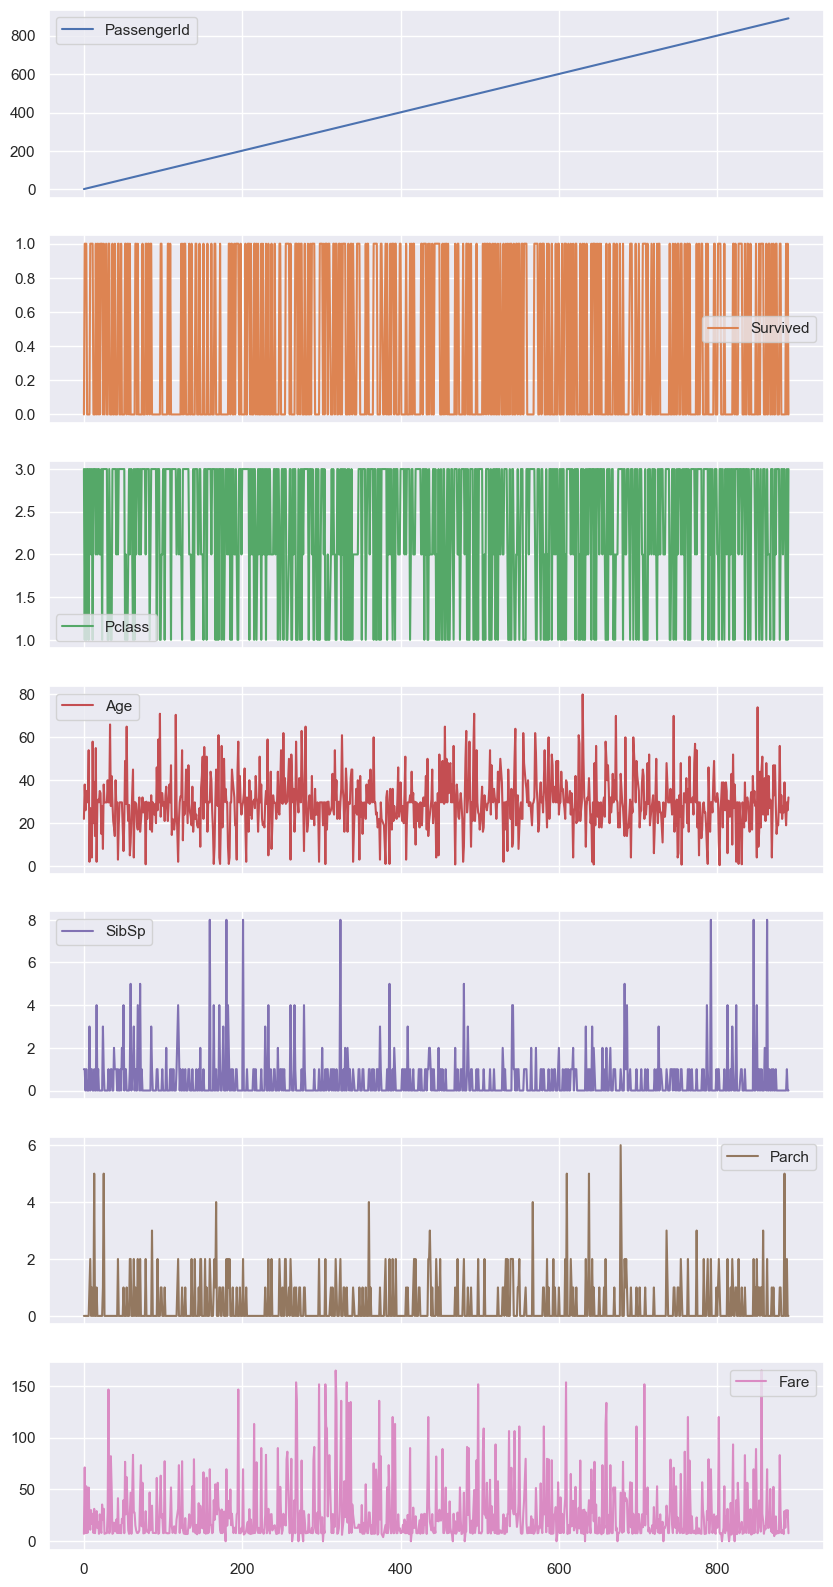

In [317]:
data = data[data['Fare'] < 200]
data.plot(subplots=True , figsize=(10,20))

##### Converting Categorical Features 

In [319]:
data['Sex'].value_counts()

Sex
male      569
female    300
Name: count, dtype: int64

In [320]:
sex = pd.get_dummies(data['Sex'],dtype='int' , drop_first='True')
sex

,male
0,1
1,0
2,0
3,0
4,1
...,...
886,1
887,0
888,0
889,1


In [321]:
data['Embarked'].value_counts()

Embarked
S    636
C    156
Q     77
Name: count, dtype: int64

In [322]:
emb = pd.get_dummies(data['Embarked'],dtype='int')
emb

,C,Q,S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1
...,...,...,...
886,0,0,1
887,0,0,1
888,0,0,1
889,1,0,0


In [323]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [324]:
data.drop(['PassengerId' , 'Name' , 'Sex' , 'Ticket'],axis=1, inplace=True)

C:\Users\Elkhouly\AppData\Local\Temp\ipykernel_15664\3107690658.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(['PassengerId' , 'Name' , 'Sex' , 'Ticket'],axis=1, inplace=True)


In [325]:
data.drop(['Embarked'],axis=1 , inplace=True)

C:\Users\Elkhouly\AppData\Local\Temp\ipykernel_15664\3256965089.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(['Embarked'],axis=1 , inplace=True)


In [326]:
data

,Survived,Pclass,Age,SibSp,Parch,Fare
0,0,3,22.000000,1,0,7.2500
1,1,1,38.000000,1,0,71.2833
2,1,3,26.000000,0,0,7.9250
3,1,1,35.000000,1,0,53.1000
4,0,3,35.000000,0,0,8.0500
...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000
887,1,1,19.000000,0,0,30.0000
888,0,3,29.699118,1,2,23.4500
889,1,1,26.000000,0,0,30.0000


In [327]:
data = pd.concat([data,sex,emb],axis=1)
data

,Survived,Pclass,Age,SibSp,Parch,Fare,male,C,Q,S
0,0,3,22.000000,1,0,7.2500,1,0,0,1
1,1,1,38.000000,1,0,71.2833,0,1,0,0
2,1,3,26.000000,0,0,7.9250,0,0,0,1
3,1,1,35.000000,1,0,53.1000,0,0,0,1
4,0,3,35.000000,0,0,8.0500,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,1,0,0,1
887,1,1,19.000000,0,0,30.0000,0,0,0,1
888,0,3,29.699118,1,2,23.4500,0,0,0,1
889,1,1,26.000000,0,0,30.0000,1,1,0,0


In [328]:
data = data.rename({'male':'gender'},axis=1)
data

,Survived,Pclass,Age,SibSp,Parch,Fare,gender,C,Q,S
0,0,3,22.000000,1,0,7.2500,1,0,0,1
1,1,1,38.000000,1,0,71.2833,0,1,0,0
2,1,3,26.000000,0,0,7.9250,0,0,0,1
3,1,1,35.000000,1,0,53.1000,0,0,0,1
4,0,3,35.000000,0,0,8.0500,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,1,0,0,1
887,1,1,19.000000,0,0,30.0000,0,0,0,1
888,0,3,29.699118,1,2,23.4500,0,0,0,1
889,1,1,26.000000,0,0,30.0000,1,1,0,0


### Exploratory Data Analysis

<Axes: xlabel='Survived', ylabel='count'>

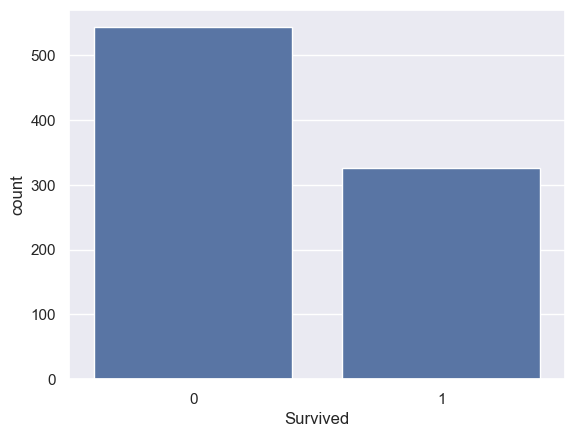

In [330]:
sns.countplot(x='Survived' , data=data)

array([[<Axes: title={'center': 'Fare'}>]], dtype=object)

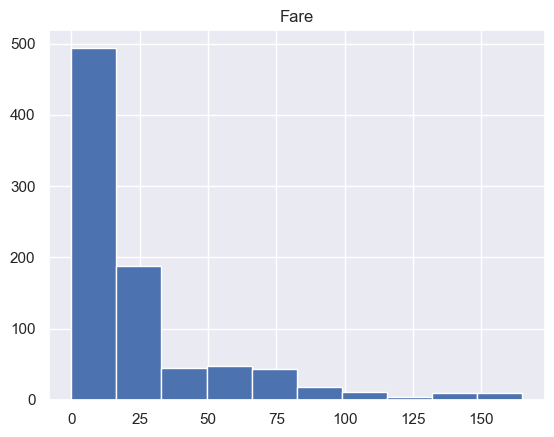

In [331]:
data.hist('Fare')

### Building Our Model

##### Train / Test Split Data

In [346]:
X = data.drop('Survived',axis=1)
y = data['Survived']

In [350]:
from sklearn.model_selection import train_test_split

In [352]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [358]:
X_train.shape

(695, 9)

##### Model Training and Predicting

In [360]:
from sklearn.linear_model import LogisticRegression

In [362]:
model = LogisticRegression(max_iter=8000)

In [364]:
model.fit(X_train,y_train)

LogisticRegression(max_iter=8000)

In [368]:
y_pred = model.predict(X_test)
y_pred

array([1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1],
      dtype=int64)

In [372]:
list(y_test)

[0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1]

##### Model Evaluation

In [374]:
from sklearn.metrics import classification_report

In [378]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.80       109
           1       0.67      0.68      0.67        65

    accuracy                           0.75       174
   macro avg       0.74      0.74      0.74       174
weighted avg       0.75      0.75      0.75       174



In [380]:
from sklearn.metrics import confusion_matrix

In [ ]:
c

==========

# THANK YOU!